# Visualizing the BA-Shapes Dataset
This notebook loads our custom BA-Shapes dataset and visualizes the graph topology. Our goal is to verify that the Barabási-Albert base graph was generated correctly and that the 5-node "house" motifs are attached and labeled accurately:
* **Label 0:** Base Graph Node (Gray)
* **Label 1:** Top of House (Orange)
* **Label 2:** Middle of House (Blue)
* **Label 3:** Bottom of House (Green)

In [1]:
import os
import sys
import yaml
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

sys.path.append(os.path.abspath('..'))

from src.data.factory import get_dataset 

torch.manual_seed(42)

In [2]:
config_path = '../config/dataset/ba_shapes.yaml'
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)

print(f"Loading dataset via factory...")
dataset = get_dataset(config)

print(f"Total Graphs Generated: {len(dataset)}")

Loading dataset via factory...
[Dataset] Found processed ba_shapes at ./data/ba_shapes/processed/ba_shapes_graph_level.pt. Loading from disk...
Total Graphs Generated: 1000


In [3]:
pos_graph_data = None
neg_graph_data = None

for data in dataset:
    if data.y.item() == 1 and pos_graph_data is None:
        pos_graph_data = data
    elif data.y.item() == 0 and neg_graph_data is None:
        neg_graph_data = data
        
    if pos_graph_data and neg_graph_data:
        break

print(f"Positive Graph (House): {pos_graph_data.num_nodes} nodes, {pos_graph_data.num_edges} edges.")
print(f"Negative Graph (No House): {neg_graph_data.num_nodes} nodes, {neg_graph_data.num_edges} edges.")

if hasattr(pos_graph_data, 'spatial_pos'):
    print(f"Graphormer spatial_pos matrix shape: {pos_graph_data.spatial_pos.shape}")

Positive Graph (House): 20 nodes, 42 edges.
Negative Graph (No House): 20 nodes, 38 edges.
Graphormer spatial_pos matrix shape: torch.Size([20, 20])


### 1. Macro-View
First, let's look at the entire graph. We use a spring layout which naturally pushes highly connected nodes (the BA core) to the center and less connected nodes (the houses) to the edges.

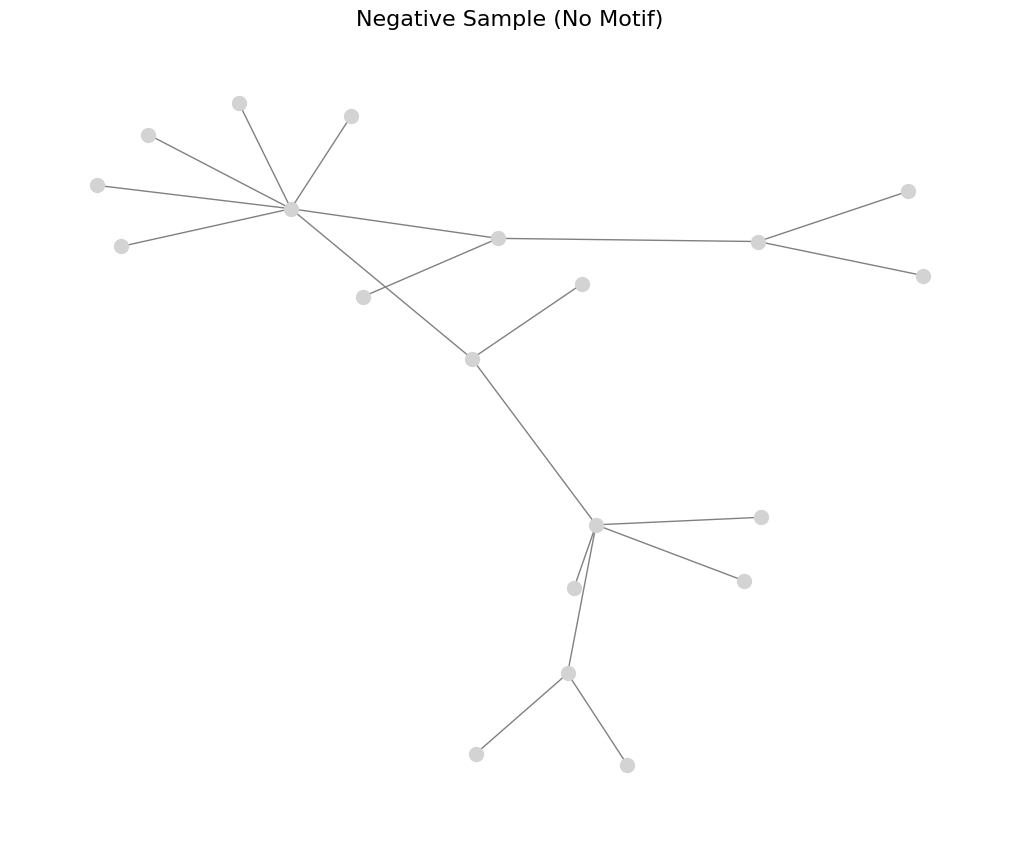

In [4]:
G_neg = to_networkx(neg_graph_data, to_undirected=True)

plt.figure(figsize=(10, 8))
pos_neg = nx.spring_layout(G_neg, seed=42)

nx.draw(
    G_neg, pos_neg, 
    node_size=100, 
    node_color='lightgray', 
    edge_color='gray',
    with_labels=False
)
plt.title("Negative Sample (No Motif)", fontsize=16)
plt.show()

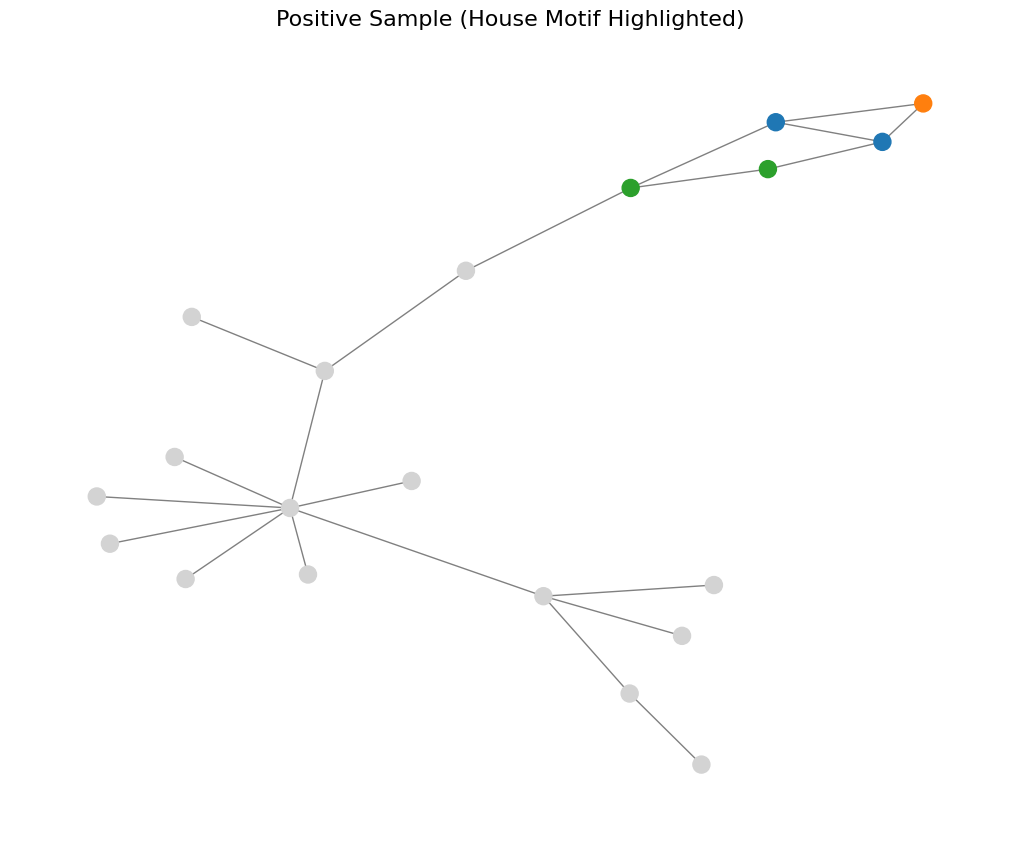

In [5]:
G_pos = to_networkx(pos_graph_data, to_undirected=True)
num_nodes = G_pos.number_of_nodes()


node_colors = []
for n in G_pos.nodes():
    if n < num_nodes - 5:
        node_colors.append('lightgray')  # Base nodes
    elif n == num_nodes - 5:
        node_colors.append('#ff7f0e')    # Top (Orange)
    elif n in [num_nodes - 4, num_nodes - 3]:
        node_colors.append('#1f77b4')    # Middle (Blue)
    else:
        node_colors.append('#2ca02c')    # Bottom (Green)

plt.figure(figsize=(10, 8))
pos_pos = nx.spring_layout(G_pos, seed=42)

nx.draw(
    G_pos, pos_pos, 
    node_size=150, 
    node_color=node_colors, 
    edge_color='gray',
    with_labels=False
)
plt.title("Positive Sample (House Motif Highlighted)", fontsize=16)
plt.show()

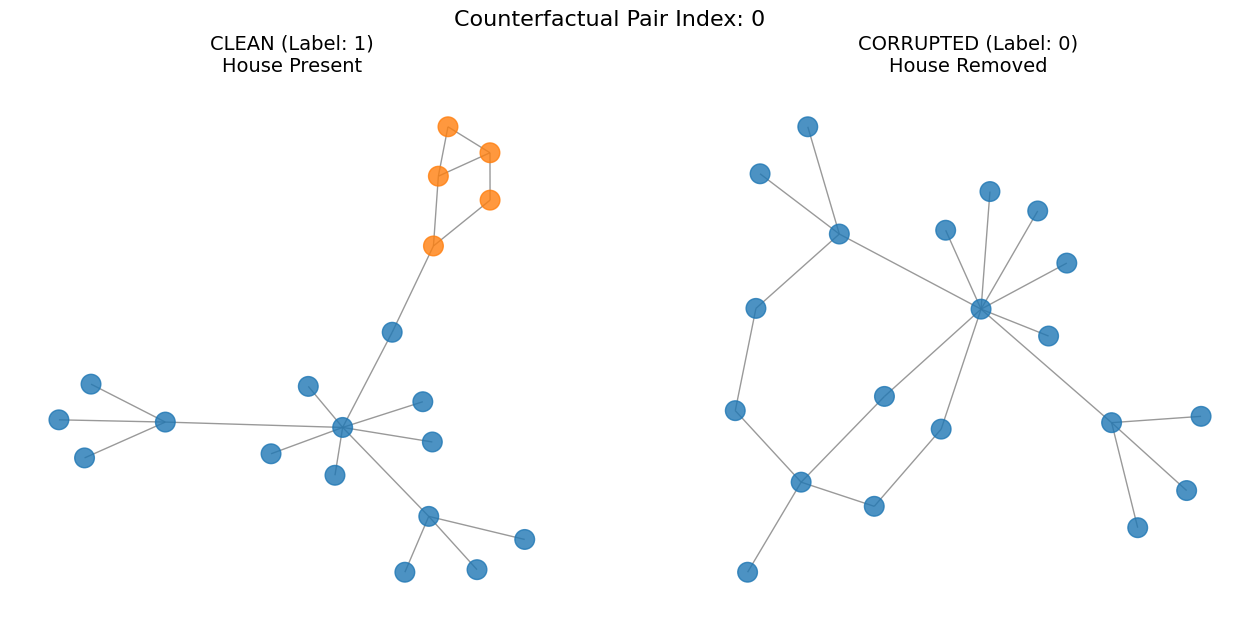

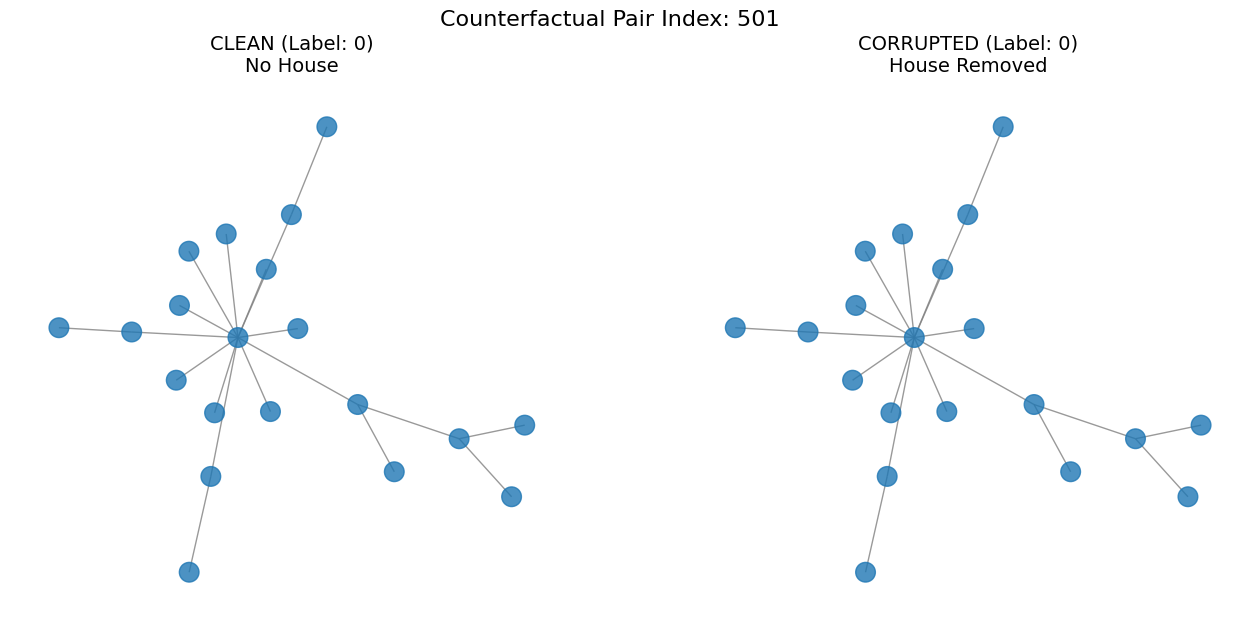

In [6]:
import torch
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

dataset_name = "ba_shapes"
cf_path = f"../data/{dataset_name}/counterfactuals.pt"
pairs = torch.load(cf_path, weights_only=False)

def plot_pair(index):
    pair = pairs[index]
    clean_data = pair['clean']
    corr_data = pair['corrupted']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    def get_colors(data):
        G = to_networkx(data, to_undirected=True)
        colors = []
        num_nodes = data.num_nodes
        for i in range(num_nodes):
            if data.y == 1 and i >= num_nodes - 5:
                colors.append('#ff7f0e') 
            else:
                colors.append('#1f77b4') 
        return G, colors

    G_clean, colors_clean = get_colors(clean_data)
    pos_clean = nx.spring_layout(G_clean, seed=42)
    nx.draw(G_clean, pos_clean, node_color=colors_clean, node_size=200, ax=ax1, edge_color='gray', alpha=0.8)
    ax1.set_title(f"CLEAN (Label: {clean_data.y.item()})\n{'House Present' if clean_data.y == 1 else 'No House'}", fontsize=14)

    G_corr, colors_corr = get_colors(corr_data)
    pos_corr = nx.spring_layout(G_corr, seed=42)
    nx.draw(G_corr, pos_corr, node_color=colors_corr, node_size=200, ax=ax2, edge_color='gray', alpha=0.8)
    ax2.set_title(f"CORRUPTED (Label: {corr_data.y.item()})\n{'House Added' if corr_data.y == 1 else 'House Removed'}", fontsize=14)

    plt.suptitle(f"Counterfactual Pair Index: {index}", fontsize=16)
    plt.show()

plot_pair(0) 

plot_pair(len(pairs) // 2 + 1)